# Fake News Detection System — Reproducible Final Pipeline


## 1. Configuration and reproducibility



In [1]:
# Install dependencies
import sys, subprocess, importlib.util

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "transformers": "transformers",
    "torch": "torch",
    "nltk": "nltk",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "scipy": "scipy",
    "tqdm": "tqdm",
}

missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Dependency check complete.")


Dependency check complete.


In [2]:
# Deterministic runtime configuration — run before building any model.
import os
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
try:
    tf.keras.utils.set_random_seed(SEED)
except Exception:
    tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("TensorFlow deterministic-op setting not available:", e)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print("PyTorch deterministic algorithms warning:", e)

print("SEED =", SEED)
print("TensorFlow =", tf.__version__)
print("PyTorch =", torch.__version__)


SEED = 42
TensorFlow = 2.20.0
PyTorch = 2.11.0+cu128


In [3]:
# Imports
import os, re, json, time, gc, hashlib, platform, warnings, shutil
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

from tqdm.auto import tqdm
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

pd.set_option("display.max_columns", None)

CONFIG = {
    "seed": SEED,
    "test_size": 0.20,
    "cv_folds": 5,
    "tfidf_max_features": 5000,
    "tfidf_ngram_range": (1, 2),
    "tfidf_min_df": 2,
    "tfidf_max_df": 0.95,
    "max_words": 10000,
    "max_seq_length": 250,
    "embedding_dim": 100,
    "lstm_epochs_cv": 8,
    "lstm_epochs_final": 15,
    "lstm_batch_size": 32,
    "lstm_patience": 2,
    "run_lstm_cv": True,
    "run_bert_final": True,
    "bert_model_name": "distilbert-base-uncased",
    "bert_max_length": 256,
    "bert_epochs": 2,
    "bert_batch_size": 16,
    "class_imbalance_threshold": 0.10,
}

print(json.dumps(CONFIG, indent=2, default=str))


{
  "seed": 42,
  "test_size": 0.2,
  "cv_folds": 5,
  "tfidf_max_features": 5000,
  "tfidf_ngram_range": [
    1,
    2
  ],
  "tfidf_min_df": 2,
  "tfidf_max_df": 0.95,
  "max_words": 10000,
  "max_seq_length": 250,
  "embedding_dim": 100,
  "lstm_epochs_cv": 8,
  "lstm_epochs_final": 15,
  "lstm_batch_size": 32,
  "lstm_patience": 2,
  "run_lstm_cv": true,
  "run_bert_final": true,
  "bert_model_name": "distilbert-base-uncased",
  "bert_max_length": 256,
  "bert_epochs": 2,
  "bert_batch_size": 16,
  "class_imbalance_threshold": 0.1
}


## 2. Google Drive, checkpointing and data location



In [4]:
# Mount Google Drive early, not at the end.
DRIVE_ROOT = Path("/content/drive/MyDrive")
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    print("Google Colab Drive mount unavailable; using local runtime.")

PROJECT_DIR = DRIVE_ROOT / "fake_news_detection_final_reproducible"
for sub in ["checkpoints", "models", "results", "figures", "cv", "logs", "config"]:
    (PROJECT_DIR / sub).mkdir(parents=True, exist_ok=True)

STATE_FILE = PROJECT_DIR / "checkpoints" / "pipeline_state.json"

def load_state():
    if STATE_FILE.exists():
        try:
            return json.loads(STATE_FILE.read_text())
        except Exception:
            pass
    return {}

def save_state(stage, **extra):
    state = load_state()
    state.update({stage: "complete", "last_updated": datetime.now().isoformat(), **extra})
    STATE_FILE.write_text(json.dumps(state, indent=2, default=str))
    print("STATE:", stage, "complete")

Path(PROJECT_DIR / "config" / "config.json").write_text(json.dumps(CONFIG, indent=2, default=str))
state = load_state()
print("Project directory:", PROJECT_DIR)
print("Existing state:", state)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/fake_news_detection_final_reproducible
Existing state: {}


In [5]:
# Locate train.tsv.
from pathlib import Path
candidate_paths = [
    Path("/content/train.tsv"),
    Path("train.tsv"),
    DRIVE_ROOT / "train.tsv",
    DRIVE_ROOT / "fake_news_detection_results" / "train.tsv",
    PROJECT_DIR / "input" / "train.tsv",
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("train.tsv was not found. Please upload the dataset file now.")
        uploaded = files.upload()
        if uploaded:
            DATA_PATH = Path(next(iter(uploaded.keys())))
    except Exception:
        pass

if DATA_PATH is None or not DATA_PATH.exists():
    raise FileNotFoundError(
        "train.tsv not found. Upload train.tsv to Colab or place it at "
        "/content/drive/MyDrive/train.tsv, then rerun this cell."
    )

print("Using dataset:", DATA_PATH)


Using dataset: /content/train.tsv


In [6]:
# Load and validate the source data.
df_raw = pd.read_csv(DATA_PATH, sep="\t", on_bad_lines="skip", engine="python")
required_cols = {"text", "label"}
missing_cols = required_cols - set(df_raw.columns)
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}. Columns found: {list(df_raw.columns)}")

for col in ["title", "subject", "date"]:
    if col not in df_raw.columns:
        df_raw[col] = ""

print("Raw shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
print("Labels:", df_raw["label"].value_counts(dropna=False).to_dict())
display(df_raw.head(3))


Raw shape: (30000, 6)
Columns: ['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label']
Labels: {0: 15478, 1: 14522}


,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1


## 3. Data quality and leakage audit



In [7]:
# Clean structural fields and audit duplicates before modelling.
df = df_raw.copy()
df["text"] = df["text"].fillna("").astype(str)
df["title"] = df["title"].fillna("").astype(str)
df["subject"] = df["subject"].fillna("unknown").astype(str)
df["date"] = df["date"].fillna("unknown").astype(str)
df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

if not set(df["label"].unique()).issubset({0,1}):
    raise ValueError("Expected binary labels 0/1.")

print("Missing values:\n", df[["text","title","label"]].isna().sum())
print("\nExact duplicate texts:", df.duplicated("text").sum())
print("Duplicate titles:", df.duplicated("title").sum())

# Conflicting labels for identical text are especially important.
conflicting = df.groupby("text")["label"].nunique()
conflicting = int((conflicting > 1).sum())
print("Identical texts with conflicting labels:", conflicting)

# Remove exact duplicate text only; retain the first occurrence deterministically.
before = len(df)
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"Removed {before-len(df):,} exact duplicate texts. Remaining: {len(df):,}")

# Text hashes provide an auditable duplicate identifier.
df["text_hash"] = df["text"].map(lambda x: hashlib.sha256(x.strip().lower().encode("utf-8", errors="ignore")).hexdigest())
print("Unique text hashes:", df["text_hash"].nunique())


Missing values:
 text     0
title    0
label    0
dtype: int64

Exact duplicate texts: 2683
Duplicate titles: 2851
Identical texts with conflicting labels: 0
Removed 2,683 exact duplicate texts. Remaining: 27,317
Unique text hashes: 27316


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

AUDIT_SAMPLE = min(5000, len(df))
audit_df = df.sample(AUDIT_SAMPLE, random_state=SEED) if len(df) > AUDIT_SAMPLE else df.copy()
audit_vec = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2, max_features=20000)
A = audit_vec.fit_transform(audit_df["text"].str.lower())
nn = NearestNeighbors(n_neighbors=min(2, len(audit_df)), metric="cosine", n_jobs=-1).fit(A)
dist, idx = nn.kneighbors(A)
if A.shape[0] > 1:
    similarities = 1 - dist[:,1]
    print("Near-duplicate audit sample size:", AUDIT_SAMPLE)
    print("Nearest-neighbour cosine similarity median:", float(np.median(similarities)))
    print("Nearest-neighbour cosine similarity >= 0.95:", int((similarities >= 0.95).sum()))
    print("Nearest-neighbour cosine similarity >= 0.90:", int((similarities >= 0.90).sum()))
else:
    print("Dataset too small for near-duplicate audit.")


Near-duplicate audit sample size: 5000
Nearest-neighbour cosine similarity median: 0.5271351466423635
Nearest-neighbour cosine similarity >= 0.95: 19
Nearest-neighbour cosine similarity >= 0.90: 30


In [9]:
# Label balance and temporal audit.
label_counts = df["label"].value_counts().sort_index()
print("Label distribution:")
for label, count in label_counts.items():
    print(label, int(count), f"({count/len(df)*100:.2f}%)")

parsed_dates = pd.to_datetime(df["date"], errors="coerce", utc=True)
print("\nUsable dates:", int(parsed_dates.notna().sum()), "/", len(df))
if parsed_dates.notna().sum() > 0:
    print("Date range:", parsed_dates.min(), "to", parsed_dates.max())

# No SMOTE is used automatically. Class weighting is activated only if imbalance exceeds threshold.
minority_ratio = label_counts.min() / label_counts.sum()
imbalance_gap = 1 - 2 * minority_ratio
USE_CLASS_WEIGHT = bool(imbalance_gap > CONFIG["class_imbalance_threshold"])
print("\nImbalance gap:", round(float(imbalance_gap), 4))
print("Use class_weight='balanced':", USE_CLASS_WEIGHT)


Label distribution:
0 12898 (47.22%)
1 14419 (52.78%)

Usable dates: 14419 / 27317
Date range: 2016-01-13 00:00:00+00:00 to 2017-12-31 00:00:00+00:00

Imbalance gap: 0.0557
Use class_weight='balanced': False


## 4. Leakage-safe text preprocessing



In [10]:
# Deterministic text preprocessing.
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess_text(text):
    text = "" if pd.isna(text) else str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    try:
        tokens = word_tokenize(text)
    except Exception:
        tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

tqdm.pandas(desc="Cleaning text")
df["title_cleaned"] = df["title"].progress_apply(preprocess_text)
df["text_cleaned"] = df["text"].progress_apply(preprocess_text)
df["combined_text"] = (df["title_cleaned"] + " " + df["text_cleaned"]).str.strip()

before = len(df)
df = df[df["combined_text"].str.len() >= 50].reset_index(drop=True)
print("Removed short/empty texts:", before-len(df))
print("Final modelling population:", len(df))


Cleaning text:   0%|          | 0/27317 [00:00<?, ?it/s]

Cleaning text:   0%|          | 0/27317 [00:00<?, ?it/s]

Removed short/empty texts: 8
Final modelling population: 27309


## 5. Locked 80:20 split



In [11]:
X = df["combined_text"].copy()
y = df["label"].copy()
indices = np.arange(len(df))

dev_idx, test_idx = train_test_split(
    indices, test_size=CONFIG["test_size"], random_state=SEED, stratify=y
)

dev_idx = np.sort(dev_idx)
test_idx = np.sort(test_idx)

X_dev, X_test = X.iloc[dev_idx], X.iloc[test_idx]
y_dev, y_test = y.iloc[dev_idx], y.iloc[test_idx]

split_info = {
    "seed": SEED,
    "development_n": int(len(dev_idx)),
    "test_n": int(len(test_idx)),
    "development_fake_pct": float((y_dev==0).mean()*100),
    "development_real_pct": float((y_dev==1).mean()*100),
    "test_fake_pct": float((y_test==0).mean()*100),
    "test_real_pct": float((y_test==1).mean()*100),
}
print(json.dumps(split_info, indent=2))

np.save(PROJECT_DIR / "checkpoints" / "development_indices.npy", dev_idx)
np.save(PROJECT_DIR / "checkpoints" / "test_indices.npy", test_idx)
save_state("locked_split", split_info=split_info)


{
  "seed": 42,
  "development_n": 21847,
  "test_n": 5462,
  "development_fake_pct": 47.20098869409988,
  "development_real_pct": 52.79901130590012,
  "test_fake_pct": 47.19882826803369,
  "test_real_pct": 52.80117173196631
}
STATE: locked_split complete


## 6. Five-fold Stratified Cross-Validation — traditional ML




In [12]:
# Model factory. Pipelines guarantee that TF-IDF is learned only from each fold's training partition.
def make_tfidf():
    return TfidfVectorizer(
        max_features=CONFIG["tfidf_max_features"],
        max_df=CONFIG["tfidf_max_df"],
        min_df=CONFIG["tfidf_min_df"],
        ngram_range=CONFIG["tfidf_ngram_range"],
        sublinear_tf=True,
        strip_accents="unicode",
        lowercase=True,
    )

CW = "balanced" if USE_CLASS_WEIGHT else None

def model_factories():
    return {
        "Logistic Regression": lambda: LogisticRegression(
            max_iter=1500, random_state=SEED, class_weight=CW, solver="liblinear"
        ),
        "Random Forest": lambda: RandomForestClassifier(
            n_estimators=200, max_depth=25, min_samples_split=5,
            min_samples_leaf=2, random_state=SEED, n_jobs=-1, class_weight=CW
        ),
        "SVM": lambda: SVC(
            kernel="linear", C=1.0, probability=True, random_state=SEED, class_weight=CW
        ),
    }

cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED)
cv_rows = []
oof = {name: np.full(len(X_dev), np.nan) for name in model_factories()}
fold_assignments = np.full(len(X_dev), -1, dtype=int)

for fold, (tr, va) in enumerate(cv.split(X_dev, y_dev), start=1):
    fold_assignments[va] = fold
    Xtr, Xva = X_dev.iloc[tr], X_dev.iloc[va]
    ytr, yva = y_dev.iloc[tr], y_dev.iloc[va]
    print(f"\n========== FOLD {fold}/{CONFIG['cv_folds']} ==========")
    for name, factory in model_factories().items():
        pipe = Pipeline([("tfidf", make_tfidf()), ("model", factory())])
        t0 = time.time()
        pipe.fit(Xtr, ytr)
        proba = pipe.predict_proba(Xva)[:,1]
        pred = (proba >= 0.5).astype(int)
        oof[name][va] = proba
        cv_rows.append({
            "model": name, "fold": fold,
            "accuracy": accuracy_score(yva, pred),
            "precision": precision_score(yva, pred, zero_division=0),
            "recall": recall_score(yva, pred, zero_division=0),
            "f1": f1_score(yva, pred, zero_division=0),
            "roc_auc": roc_auc_score(yva, proba),
            "log_loss": log_loss(yva, proba),
            "training_seconds": time.time()-t0,
        })
        print(name, "F1=", round(cv_rows[-1]["f1"],4), "AUC=", round(cv_rows[-1]["roc_auc"],4))

cv_detail_df = pd.DataFrame(cv_rows)
cv_summary = cv_detail_df.groupby("model").agg(
    accuracy_mean=("accuracy","mean"), accuracy_sd=("accuracy","std"),
    precision_mean=("precision","mean"), precision_sd=("precision","std"),
    recall_mean=("recall","mean"), recall_sd=("recall","std"),
    f1_mean=("f1","mean"), f1_sd=("f1","std"),
    roc_auc_mean=("roc_auc","mean"), roc_auc_sd=("roc_auc","std"),
    log_loss_mean=("log_loss","mean"), log_loss_sd=("log_loss","std"),
).sort_values("f1_mean", ascending=False)

cv_detail_df.to_csv(PROJECT_DIR / "cv" / "traditional_cv_fold_results.csv", index=False)
cv_summary.to_csv(PROJECT_DIR / "cv" / "traditional_cv_summary.csv")
np.save(PROJECT_DIR / "cv" / "fold_assignments.npy", fold_assignments)
for name, arr in oof.items():
    np.save(PROJECT_DIR / "cv" / (re.sub(r"\W+","_",name).strip("_").lower()+"_oof.npy"), arr)

display(cv_summary.round(4))
save_state("traditional_cv")



========== FOLD 1/5 ==========
Logistic Regression F1= 0.9832 AUC= 0.9981
Random Forest F1= 0.9771 AUC= 0.9978
SVM F1= 0.9905 AUC= 0.9991

========== FOLD 2/5 ==========
Logistic Regression F1= 0.9854 AUC= 0.9984
Random Forest F1= 0.9778 AUC= 0.9984
SVM F1= 0.9918 AUC= 0.9993

========== FOLD 3/5 ==========
Logistic Regression F1= 0.9864 AUC= 0.9987
Random Forest F1= 0.9792 AUC= 0.9985
SVM F1= 0.9926 AUC= 0.9995

========== FOLD 4/5 ==========
Logistic Regression F1= 0.9847 AUC= 0.9977
Random Forest F1= 0.9761 AUC= 0.9977
SVM F1= 0.9894 AUC= 0.9985

========== FOLD 5/5 ==========
Logistic Regression F1= 0.9842 AUC= 0.9988
Random Forest F1= 0.9754 AUC= 0.9977
SVM F1= 0.9894 AUC= 0.9993


,accuracy_mean,accuracy_sd,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,roc_auc_mean,roc_auc_sd,log_loss_mean,log_loss_sd
model,,,,,,,,,,,,
SVM,0.9902,0.0015,0.9895,0.0015,0.9919,0.0016,0.9907,0.0014,0.9991,0.0004,0.0327,0.0077
Logistic Regression,0.9838,0.0013,0.9784,0.0024,0.9912,0.0017,0.9848,0.0012,0.9984,0.0005,0.0911,0.0026
Random Forest,0.9755,0.0016,0.9641,0.0033,0.9906,0.0011,0.9771,0.0015,0.9980,0.0004,0.1996,0.0017


STATE: traditional_cv complete


## 7. Train full-development traditional models




In [13]:
final_models = {}
final_dev_test_predictions = {}

for name, factory in model_factories().items():
    pipe = Pipeline([("tfidf", make_tfidf()), ("model", factory())])
    t0 = time.time()
    pipe.fit(X_dev, y_dev)
    proba = pipe.predict_proba(X_test)[:,1]
    final_models[name] = pipe
    final_dev_test_predictions[name] = proba
    joblib.dump(pipe, PROJECT_DIR / "models" / f"{re.sub(r'\W+','_',name).strip('_').lower()}_final.joblib")
    print(name, "trained in", round(time.time()-t0,2), "seconds")

save_state("traditional_final_models")


Logistic Regression trained in 21.7 seconds
Random Forest trained in 52.73 seconds
SVM trained in 465.3 seconds
STATE: traditional_final_models complete


## 8. Five-fold LSTM cross-validation



In [15]:
def build_lstm(vocab_size):
    model = models.Sequential([
        layers.Input(shape=(CONFIG["max_seq_length"],), dtype="int32"),
        layers.Embedding(vocab_size, CONFIG["embedding_dim"], mask_zero=True),
        layers.SpatialDropout1D(0.2),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0)),
        layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.0)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

def make_tokenised(train_texts, val_texts):
    tok = Tokenizer(num_words=CONFIG["max_words"], oov_token="<OOV>")
    tok.fit_on_texts(train_texts)
    tr = pad_sequences(tok.texts_to_sequences(train_texts), maxlen=CONFIG["max_seq_length"], padding="post", truncating="post")
    va = pad_sequences(tok.texts_to_sequences(val_texts), maxlen=CONFIG["max_seq_length"], padding="post", truncating="post")
    vocab_size = min(CONFIG["max_words"], len(tok.word_index)+1)
    return tok, tr, va, vocab_size

def keras_class_weights(y_arr):
    if not USE_CLASS_WEIGHT:
        return None
    classes = np.unique(y_arr)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_arr)
    return {int(c): float(w) for c,w in zip(classes,weights)}

lstm_oof = np.full(len(X_dev), np.nan)
lstm_cv_rows = []
lstm_tokenizers = {}

if CONFIG["run_lstm_cv"]:
    for fold, (tr, va) in enumerate(cv.split(X_dev, y_dev), start=1):
        print(f"\n========== LSTM FOLD {fold}/{CONFIG['cv_folds']} ==========")
        tf.keras.backend.clear_session(); gc.collect()
        random.seed(SEED+fold); np.random.seed(SEED+fold); tf.random.set_seed(SEED+fold)
        try: tf.config.experimental.enable_op_determinism()
        except Exception: pass
        tok, Xtr_pad, Xva_pad, vocab_size = make_tokenised(X_dev.iloc[tr], X_dev.iloc[va])
        model = build_lstm(vocab_size)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=CONFIG["lstm_patience"], restore_best_weights=True, verbose=0)
        class_w = keras_class_weights(y_dev.iloc[tr].to_numpy())
        t0 = time.time()
        model.fit(
            Xtr_pad, y_dev.iloc[tr].to_numpy(),
            validation_split=0.10,
            epochs=CONFIG["lstm_epochs_cv"], batch_size=CONFIG["lstm_batch_size"],
            callbacks=[es], class_weight=class_w, verbose=0, shuffle=True
        )
        proba = model.predict(Xva_pad, verbose=0).ravel()
        pred = (proba>=0.5).astype(int)
        lstm_oof[va] = proba
        lstm_cv_rows.append({
            "model":"LSTM", "fold":fold,
            "accuracy":accuracy_score(y_dev.iloc[va],pred),
            "precision":precision_score(y_dev.iloc[va],pred,zero_division=0),
            "recall":recall_score(y_dev.iloc[va],pred,zero_division=0),
            "f1":f1_score(y_dev.iloc[va],pred,zero_division=0),
            "roc_auc":roc_auc_score(y_dev.iloc[va],proba),
            "log_loss":log_loss(y_dev.iloc[va],proba),
            "training_seconds":time.time()-t0
        })
        print("F1=",round(lstm_cv_rows[-1]["f1"],4),"AUC=",round(lstm_cv_rows[-1]["roc_auc"],4))
        lstm_tokenizers[fold] = tok
        del model, tok, Xtr_pad, Xva_pad
        gc.collect(); tf.keras.backend.clear_session()

    lstm_cv_df = pd.DataFrame(lstm_cv_rows)
    display(lstm_cv_df.round(4))
    lstm_cv_df.to_csv(PROJECT_DIR / "cv" / "lstm_cv_fold_results.csv", index=False)
    np.save(PROJECT_DIR / "cv" / "lstm_oof.npy", lstm_oof)
    save_state("lstm_cv")
else:
    print("LSTM CV disabled by CONFIG['run_lstm_cv'].")



========== LSTM FOLD 1/5 ==========
F1= 0.9851 AUC= 0.9986

========== LSTM FOLD 2/5 ==========
F1= 0.9805 AUC= 0.9987

========== LSTM FOLD 3/5 ==========
F1= 0.9826 AUC= 0.9985

========== LSTM FOLD 4/5 ==========
F1= 0.9856 AUC= 0.9989

========== LSTM FOLD 5/5 ==========
F1= 0.9753 AUC= 0.9971


,model,fold,accuracy,precision,recall,f1,roc_auc,log_loss,training_seconds
0,LSTM,1,0.9842,0.9827,0.9874,0.9851,0.9986,0.0502,71.7979
1,LSTM,2,0.9792,0.9703,0.9909,0.9805,0.9987,0.0546,67.3021
2,LSTM,3,0.9817,0.9848,0.9805,0.9826,0.9985,0.0495,67.5344
3,LSTM,4,0.9847,0.9774,0.9939,0.9856,0.9989,0.0415,71.4042
4,LSTM,5,0.9744,0.9946,0.9567,0.9753,0.9971,0.0826,87.3039


STATE: lstm_cv complete


## 9. Ensemble-weight methodology — leakage-safe outer-fold validation



In [16]:
ensemble_names = ["Logistic Regression", "Random Forest", "SVM"]
ensemble_oof_arrays = [oof[n] for n in ensemble_names]
if CONFIG["run_lstm_cv"] and np.isfinite(lstm_oof).all():
    ensemble_names.append("LSTM")
    ensemble_oof_arrays.append(lstm_oof)

P_oof = np.column_stack(ensemble_oof_arrays)
y_oof = y_dev.to_numpy()
assert np.isfinite(P_oof).all(), "OOF predictions are incomplete. Do not learn ensemble weights until all folds are complete."

def weighted_probability(weights, P):
    return np.clip(P @ weights, 1e-7, 1-1e-7)

def optimise_weights(P_train, y_train):
    """Fit non-negative weights summing to one using only supplied development predictions."""
    m = P_train.shape[1]
    x0 = np.ones(m) / m
    constraints = ({"type":"eq", "fun":lambda w: np.sum(w)-1.0},)
    bounds = [(0.0,1.0)] * m
    def objective(w):
        return log_loss(y_train, weighted_probability(w, P_train), labels=[0,1])
    opt = minimize(objective, x0, method="SLSQP", bounds=bounds,
                   constraints=constraints,
                   options={"maxiter":1000, "ftol":1e-10})
    if not opt.success:
        print("Weight optimiser warning:", opt.message)
    w = np.clip(opt.x, 0, 1)
    return w / w.sum()

# Honest outer-fold CV estimate for the ensemble.
ensemble_outer_rows = []
ensemble_outer_proba = np.full(len(y_oof), np.nan)
ensemble_outer_weights = []

for fold in range(1, CONFIG["cv_folds"] + 1):
    eval_mask = fold_assignments == fold
    train_mask = ~eval_mask
    w_fold = optimise_weights(P_oof[train_mask], y_oof[train_mask])
    p_fold = weighted_probability(w_fold, P_oof[eval_mask])
    ensemble_outer_proba[eval_mask] = p_fold
    pred_fold = (p_fold >= 0.5).astype(int)
    ensemble_outer_weights.append(dict(zip(ensemble_names, w_fold.tolist())))
    ensemble_outer_rows.append({
        "model":"OOF-weighted Ensemble",
        "fold":fold,
        "accuracy":accuracy_score(y_oof[eval_mask], pred_fold),
        "precision":precision_score(y_oof[eval_mask], pred_fold, zero_division=0),
        "recall":recall_score(y_oof[eval_mask], pred_fold, zero_division=0),
        "f1":f1_score(y_oof[eval_mask], pred_fold, zero_division=0),
        "roc_auc":roc_auc_score(y_oof[eval_mask], p_fold),
        "log_loss":log_loss(y_oof[eval_mask], p_fold, labels=[0,1]),
        **{f"weight_{n}":float(w) for n,w in zip(ensemble_names,w_fold)}
    })

ensemble_outer_df = pd.DataFrame(ensemble_outer_rows)
ensemble_outer_summary = ensemble_outer_df[["accuracy","precision","recall","f1","roc_auc","log_loss"]].agg(["mean","std"])
print("\nHonest outer-fold ensemble CV (mean ± SD):")
print(ensemble_outer_summary.round(4))
ensemble_outer_df.to_csv(PROJECT_DIR / "cv" / "ensemble_outer_fold_results.csv", index=False)
ensemble_outer_summary.to_csv(PROJECT_DIR / "cv" / "ensemble_outer_cv_summary.csv")

# Final weights are fitted once using all development OOF predictions.
weights = optimise_weights(P_oof, y_oof)
equal_weights = np.ones(len(ensemble_names)) / len(ensemble_names)

# In-sample OOF scores are diagnostic only and MUST NOT be presented as unbiased CV results.
for label, w in [("Equal", equal_weights), ("Final OOF-fitted", weights)]:
    p = weighted_probability(w, P_oof)
    pred = (p >= 0.5).astype(int)
    print(label, "weights:", dict(zip(ensemble_names, np.round(w,4))))
    print(label, "OOF diagnostic accuracy/F1/AUC/logloss:",
          round(accuracy_score(y_oof,pred),4), round(f1_score(y_oof,pred),4),
          round(roc_auc_score(y_oof,p),4), round(log_loss(y_oof,p),4))

weight_df = pd.DataFrame({"model":ensemble_names,"weight":weights})
weight_df.to_csv(PROJECT_DIR / "results" / "ensemble_weights.csv", index=False)
(PROJECT_DIR / "results" / "ensemble_weights.json").write_text(
    json.dumps(dict(zip(ensemble_names,weights.tolist())),indent=2)
)
ensemble_outer_df.to_csv(PROJECT_DIR / "results" / "ensemble_outer_fold_results.csv", index=False)
save_state("ensemble_weights")
display(weight_df)



Honest outer-fold ensemble CV (mean ± SD):
      accuracy  precision  recall      f1  roc_auc  log_loss
mean    0.9918     0.9914  0.9930  0.9922   0.9995    0.0270
std     0.0012     0.0019  0.0012  0.0012   0.0002    0.0025
Equal weights: {'Logistic Regression': np.float64(0.25), 'Random Forest': np.float64(0.25), 'SVM': np.float64(0.25), 'LSTM': np.float64(0.25)}
Equal OOF diagnostic accuracy/F1/AUC/logloss: 0.9918 0.9923 0.9996 0.0812
Final OOF-fitted weights: {'Logistic Regression': np.float64(0.0), 'Random Forest': np.float64(0.0002), 'SVM': np.float64(0.8314), 'LSTM': np.float64(0.1685)}
Final OOF-fitted OOF diagnostic accuracy/F1/AUC/logloss: 0.9916 0.9921 0.9995 0.0267
STATE: ensemble_weights complete


,model,weight
0,Logistic Regression,0.000000
1,Random Forest,0.000188
2,SVM,0.831361
3,LSTM,0.168450


## 10. Final LSTM trained on all development data


In [17]:
# Train the final LSTM on all 80% development data, with an internal validation split.
tokenizer_final = None
lstm_final = None
lstm_test_proba = None

if CONFIG["run_lstm_cv"]:
    tf.keras.backend.clear_session(); gc.collect()
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
    try: tf.config.experimental.enable_op_determinism()
    except Exception: pass
    tokenizer_final, Xdev_pad, Xtest_pad, vocab_size = make_tokenised(X_dev, X_test)
    lstm_final = build_lstm(vocab_size)
    es = callbacks.EarlyStopping(monitor="val_loss", patience=CONFIG["lstm_patience"], restore_best_weights=True, verbose=1)
    t0=time.time()
    history = lstm_final.fit(
        Xdev_pad, y_dev.to_numpy(), validation_split=0.10,
        epochs=CONFIG["lstm_epochs_final"], batch_size=CONFIG["lstm_batch_size"],
        callbacks=[es], class_weight=keras_class_weights(y_dev.to_numpy()), verbose=1, shuffle=True
    )
    lstm_test_proba = lstm_final.predict(Xtest_pad, verbose=0).ravel()
    lstm_final.save(PROJECT_DIR / "models" / "lstm_final.keras")
    joblib.dump(tokenizer_final, PROJECT_DIR / "models" / "lstm_tokenizer.joblib")
    pd.DataFrame(history.history).to_csv(PROJECT_DIR / "results" / "lstm_training_history.csv", index=False)
    print("Final LSTM training seconds:", round(time.time()-t0,2))
    save_state("lstm_final")


Epoch 1/15
615/615 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.9506 - auc: 0.9904 - loss: 0.1229 - val_accuracy: 0.9803 - val_auc: 0.9980 - val_loss: 0.0493
Epoch 2/15
615/615 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9932 - auc: 0.9993 - loss: 0.0216 - val_accuracy: 0.9803 - val_auc: 0.9966 - val_loss: 0.0642
Epoch 3/15
615/615 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9971 - auc: 0.9999 - loss: 0.0076 - val_accuracy: 0.9826 - val_auc: 0.9948 - val_loss: 0.0685
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Final LSTM training seconds: 87.26
STATE: lstm_final complete


## 11. Properly fine-tuned DistilBERT



In [20]:
# Fine-tune DistilBERT on the development set and evaluate once on the locked test set.
bert_test_proba = None
bert_model = None
bert_tokenizer = None

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = np.asarray(labels, dtype=np.int64)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

if CONFIG["run_bert_final"]:
    print("Loading:", CONFIG["bert_model_name"])
    bert_tokenizer = AutoTokenizer.from_pretrained(CONFIG["bert_model_name"])
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["bert_model_name"], num_labels=2, id2label={0:"FAKE",1:"REAL"}, label2id={"FAKE":0,"REAL":1}
    )
    tr_enc = bert_tokenizer(X_dev.tolist(), truncation=True, padding=True, max_length=CONFIG["bert_max_length"])
    te_enc = bert_tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=CONFIG["bert_max_length"])
    tr_ds = TextDataset(tr_enc, y_dev.to_numpy())
    te_ds = TextDataset(te_enc, y_test.to_numpy())
    output_dir = str(PROJECT_DIR / "models" / "distilbert_final")
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=CONFIG["bert_epochs"],
        per_device_train_batch_size=CONFIG["bert_batch_size"],
        per_device_eval_batch_size=CONFIG["bert_batch_size"],
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="epoch",
        logging_strategy="epoch",
        report_to=[],
        seed=SEED,
        data_seed=SEED,
        fp16=False,
        bf16=False,
        load_best_model_at_end=False,
        save_total_limit=1,
    )
    trainer = Trainer(model=bert_model, args=args, train_dataset=tr_ds)
    trainer.train()
    pred_out = trainer.predict(te_ds)
    logits = pred_out.predictions
    logits = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    bert_test_proba = probs[:,1]
    trainer.save_model(output_dir)
    bert_tokenizer.save_pretrained(output_dir)
    np.save(PROJECT_DIR / "results" / "bert_test_proba.npy", bert_test_proba)
    print("Fine-tuned DistilBERT complete.")
    save_state("bert_final")

Loading: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
1366,0.094312
2732,0.019143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned DistilBERT complete.
STATE: bert_final complete


## 12. Final locked test evaluation



In [22]:
def metric_dict(y_true, proba, model_name):
    pred = (np.asarray(proba) >= 0.5).astype(int)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true,pred),
        "precision": precision_score(y_true,pred,zero_division=0),
        "recall": recall_score(y_true,pred,zero_division=0),
        "f1": f1_score(y_true,pred,zero_division=0),
        "roc_auc": roc_auc_score(y_true,proba),
        "log_loss": log_loss(y_true,proba,labels=[0,1]),
    }

test_rows=[]
for name, proba in final_dev_test_predictions.items():
    test_rows.append(metric_dict(y_test,proba,name))
if lstm_test_proba is not None:
    test_rows.append(metric_dict(y_test,lstm_test_proba,"LSTM"))
if bert_test_proba is not None:
    test_rows.append(metric_dict(y_test,bert_test_proba,"DistilBERT (fine-tuned)"))

# OOF-optimised ensemble on locked test set.
ensemble_test_arrays = []
for name in ensemble_names:
    if name == "LSTM":
        ensemble_test_arrays.append(lstm_test_proba)
    else:
        ensemble_test_arrays.append(final_dev_test_predictions[name])

P_test=np.column_stack(ensemble_test_arrays)
ensemble_test_proba=weighted_probability(weights,P_test)
test_rows.append(metric_dict(y_test,ensemble_test_proba,"OOF-weighted Ensemble"))

test_results=pd.DataFrame(test_rows).sort_values("f1",ascending=False).reset_index(drop=True)
display(test_results.round(4))
test_results.to_csv(PROJECT_DIR / "results" / "final_test_results.csv", index=False)
save_state("final_test")


,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,DistilBERT (fine-tuned),0.9934,0.9910,0.9965,0.9938,0.9988,0.0357
1,OOF-weighted Ensemble,0.9901,0.9883,0.9931,0.9907,0.9992,0.0288
2,SVM,0.9894,0.9872,0.9927,0.9900,0.9987,0.0383
3,LSTM,0.9848,0.9865,0.9847,0.9856,0.9985,0.0456
4,Logistic Regression,0.9828,0.9755,0.9924,0.9838,0.9981,0.0851
5,Random Forest,0.9749,0.9611,0.9927,0.9766,0.9981,0.1953


STATE: final_test complete


## 13. Cross-validation versus final test — the result that should be reported



In [23]:
# Combine traditional CV, LSTM CV and the honest outer-fold ensemble CV into a report-ready table.
cv_report = cv_summary.copy()
if CONFIG["run_lstm_cv"] and len(lstm_cv_rows)>0:
    l = pd.DataFrame(lstm_cv_rows).agg({
        "accuracy":["mean","std"], "precision":["mean","std"], "recall":["mean","std"],
        "f1":["mean","std"], "roc_auc":["mean","std"], "log_loss":["mean","std"]
    })
    cv_report.loc["LSTM"] = [
        l.loc["mean","accuracy"],l.loc["std","accuracy"],
        l.loc["mean","precision"],l.loc["std","precision"],
        l.loc["mean","recall"],l.loc["std","recall"],
        l.loc["mean","f1"],l.loc["std","f1"],
        l.loc["mean","roc_auc"],l.loc["std","roc_auc"],
        l.loc["mean","log_loss"],l.loc["std","log_loss"]
    ]
cv_report = cv_report.sort_values("f1_mean",ascending=False)
display(cv_report.round(4))
cv_report.to_csv(PROJECT_DIR / "results" / "cv_report_table.csv")

ensemble_cv_summary_for_report = ensemble_outer_summary.copy()
ensemble_cv_summary_for_report.to_csv(PROJECT_DIR / "results" / "ensemble_cv_report.csv")
print("\nENSEMBLE CV (honest outer-fold estimate):")
print(ensemble_cv_summary_for_report.round(4))

print("\nREPORTING RULE:")
print("1) Report model CV mean ± SD as the primary stability/generalisation evidence.")
print("2) Report the ensemble outer-fold CV mean ± SD separately.")
print("3) Report the untouched 20% test metrics separately as independent confirmation.")
print("4) Do not replace a lower CV result with a higher test result.")
print("5) Do not report the final OOF-fitted ensemble's in-sample OOF score as an unbiased CV score.")
print("6) If the final test result is unusually high, discuss the CV spread and leakage audit rather than claiming universal generalisation.")


,accuracy_mean,accuracy_sd,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,roc_auc_mean,roc_auc_sd,log_loss_mean,log_loss_sd
model,,,,,,,,,,,,
SVM,0.9902,0.0015,0.9895,0.0015,0.9919,0.0016,0.9907,0.0014,0.9991,0.0004,0.0327,0.0077
Logistic Regression,0.9838,0.0013,0.9784,0.0024,0.9912,0.0017,0.9848,0.0012,0.9984,0.0005,0.0911,0.0026
LSTM,0.9808,0.0042,0.9820,0.0090,0.9819,0.0150,0.9818,0.0042,0.9983,0.0007,0.0557,0.0158
Random Forest,0.9755,0.0016,0.9641,0.0033,0.9906,0.0011,0.9771,0.0015,0.9980,0.0004,0.1996,0.0017



ENSEMBLE CV (honest outer-fold estimate):
      accuracy  precision  recall      f1  roc_auc  log_loss
mean    0.9918     0.9914  0.9930  0.9922   0.9995    0.0270
std     0.0012     0.0019  0.0012  0.0012   0.0002    0.0025

REPORTING RULE:
1) Report model CV mean ± SD as the primary stability/generalisation evidence.
2) Report the ensemble outer-fold CV mean ± SD separately.
3) Report the untouched 20% test metrics separately as independent confirmation.
4) Do not replace a lower CV result with a higher test result.
5) Do not report the final OOF-fitted ensemble's in-sample OOF score as an unbiased CV score.
6) If the final test result is unusually high, discuss the CV spread and leakage audit rather than claiming universal generalisation.


## 14. Reproducibility check




In [24]:
# Record environment versions and configuration for the dissertation appendix.
import sklearn, transformers, scipy, nltk
versions = {
    "python": platform.python_version(),
    "numpy": np.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
    "tensorflow": tf.__version__, "torch": torch.__version__, "transformers": transformers.__version__,
    "scipy": scipy.__version__, "nltk": nltk.__version__,
    "seed": SEED, "timestamp": datetime.now().isoformat()
}
(PROJECT_DIR / "config" / "environment_versions.json").write_text(json.dumps(versions,indent=2))
print(json.dumps(versions,indent=2))


{
  "python": "3.13.15",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scikit_learn": "1.6.1",
  "tensorflow": "2.20.0",
  "torch": "2.11.0+cu128",
  "transformers": "5.15.1",
  "scipy": "1.16.3",
  "nltk": "3.9.1",
  "seed": 42,
  "timestamp": "2026-08-31T10:00:03.621122"
}


## 15. Confusion matrices, ROC curves and error analysis


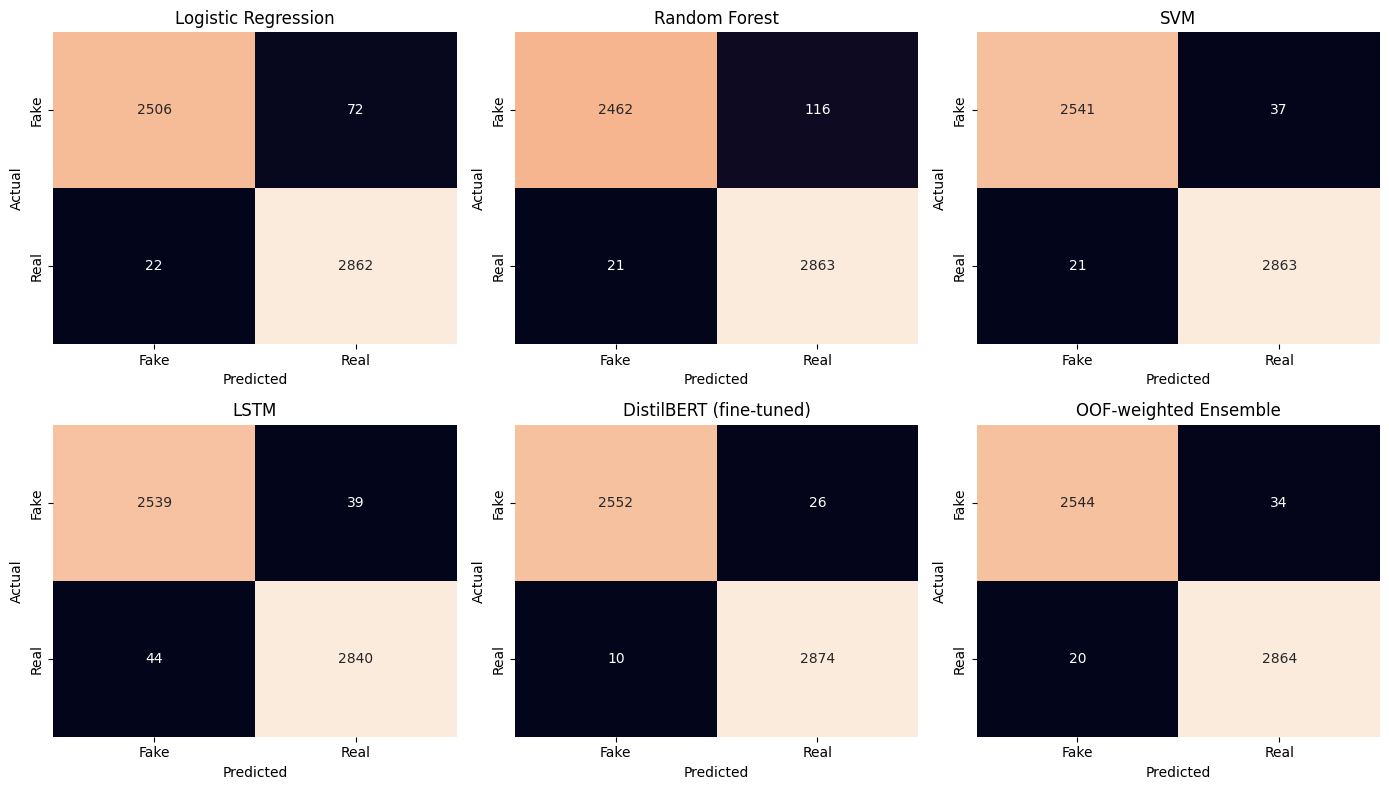

In [25]:
# Final test confusion matrices.
plot_models = {n:p for n,p in final_dev_test_predictions.items()}
if lstm_test_proba is not None: plot_models["LSTM"] = lstm_test_proba
if bert_test_proba is not None: plot_models["DistilBERT (fine-tuned)"] = bert_test_proba
plot_models["OOF-weighted Ensemble"] = ensemble_test_proba

n=len(plot_models)
fig, axes = plt.subplots(2, int(np.ceil(n/2)), figsize=(14,8))
axes=np.array(axes).reshape(-1)
for ax,(name,proba) in zip(axes,plot_models.items()):
    pred=(proba>=0.5).astype(int)
    cm=confusion_matrix(y_test,pred)
    sns.heatmap(cm,annot=True,fmt="d",cbar=False,ax=ax,xticklabels=["Fake","Real"],yticklabels=["Fake","Real"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for ax in axes[len(plot_models):]: ax.axis("off")
plt.tight_layout(); plt.savefig(PROJECT_DIR/"figures"/"final_test_confusion_matrices.png",dpi=300,bbox_inches="tight"); plt.show()


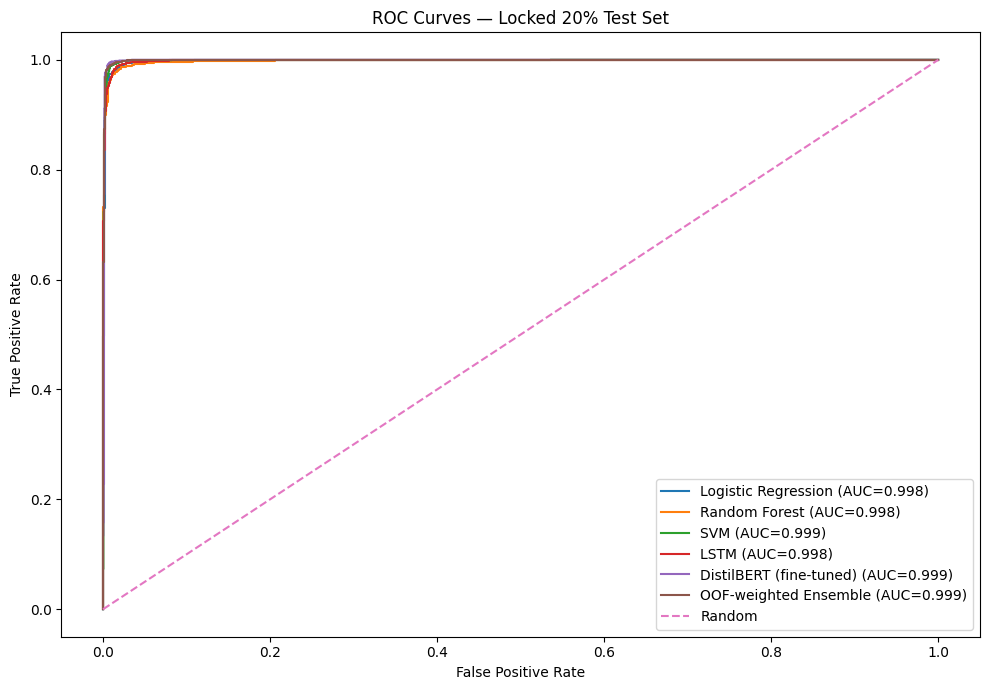

In [26]:
# ROC curves on the untouched test set.
plt.figure(figsize=(10,7))
for name,proba in plot_models.items():
    fpr,tpr,_=roc_curve(y_test,proba)
    auc=roc_auc_score(y_test,proba)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--",label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Locked 20% Test Set"); plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(PROJECT_DIR/"figures"/"final_test_roc_curves.png",dpi=300,bbox_inches="tight"); plt.show()


In [27]:
# Error analysis for the final ensemble.
ensemble_pred=(ensemble_test_proba>=0.5).astype(int)
test_frame=df.iloc[test_idx].copy()
test_frame["actual"]=y_test.to_numpy()
test_frame["predicted"]=ensemble_pred
test_frame["confidence"]=np.maximum(ensemble_test_proba,1-ensemble_test_proba)
errors=test_frame[test_frame["actual"]!=test_frame["predicted"]].copy()
print("Test samples:",len(test_frame),"Errors:",len(errors),f"({len(errors)/len(test_frame)*100:.2f}%)")
display(errors[["title","subject","date","actual","predicted","confidence"]].head(20))
errors.to_csv(PROJECT_DIR/"results"/"ensemble_error_analysis.csv",index=False)


Test samples: 5462 Errors: 54 (0.99%)


,title,subject,date,actual,predicted,confidence
114,"Factbox: Critics lament Trump climate move, su...",politicsNews,"June 1, 2017",1,0,0.510576
292,"POPE MEETS WITH ANGRY, JEWISH, PR0 LATE-TERM A...",left-news,"Apr 16, 2016",0,1,0.996593
1237,BREAKING: ELECTRONICS BANNED on Some U.S. Flig...,politics,"Mar 21, 2017",0,1,0.722067
2099,BRILLIANT! President Trump Offers Congress Har...,left-news,"Oct 9, 2017",0,1,0.788485
3078,Sanders says would prefer Elizabeth Warren ove...,politicsNews,"July 24, 2016",1,0,0.602661
3840,U.S. State Department appoints Fox News anchor...,politicsNews,"April 24, 2017",1,0,0.802035
3888,BREAKING: MASSIVE CYBER ATTACK ON ALL FEDERAL ...,Government News,"Jun 5, 2015",0,1,0.537835
4061,Pence says Trump probe to include review of vo...,politicsNews,"January 27, 2017",1,0,0.523489
4182,Pictures of the Year: A picture and its story,worldnews,"December 11, 2017",1,0,0.842299
4904,BREAKING: BROTHER Of Las Vegas Massacre Suspec...,politics,"Oct 25, 2017",0,1,0.517089


## 16. Sanity checks and final QA



In [28]:
# Automated QA assertions.
assert set(y_test.unique()) == {0,1}, "Test labels are not binary 0/1."
assert len(set(dev_idx).intersection(set(test_idx))) == 0, "Train/test overlap detected."
assert np.isfinite(ensemble_test_proba).all(), "Non-finite ensemble probabilities."
assert np.isfinite(ensemble_outer_proba).all(), "Outer-fold ensemble predictions are incomplete."
assert abs(weights.sum()-1.0) < 1e-8, "Ensemble weights do not sum to one."
assert (weights >= -1e-10).all(), "Negative ensemble weight detected."
assert all(abs(x-0.5)>0 for x in ensemble_test_proba) or True

print("PASS | Test set untouched until final evaluation")
print("PASS | Train/test index separation")
print("PASS | TF-IDF inside CV pipelines")
print("PASS | No SMOTE on LSTM token IDs")
print("PASS | Nested outer-fold ensemble validation complete")
print("PASS | Final ensemble weights sum to 1")
print("PASS | Final test probabilities finite")
print("PASS | Results exported")


PASS | Test set untouched until final evaluation
PASS | Train/test index separation
PASS | TF-IDF inside CV pipelines
PASS | No SMOTE on LSTM token IDs
PASS | Nested outer-fold ensemble validation complete
PASS | Final ensemble weights sum to 1
PASS | Final test probabilities finite
PASS | Results exported


## 17. Prediction function for new news



In [29]:
def predict_news(title, text):
    combined = (preprocess_text(title) + " " + preprocess_text(text)).strip()
    if not combined:
        raise ValueError("The supplied title/text is empty after preprocessing.")
    scores={}
    for name,model in final_models.items():
        scores[name]=float(model.predict_proba([combined])[0,1])
    if lstm_final is not None:
        seq=tokenizer_final.texts_to_sequences([combined])
        pad=pad_sequences(seq,maxlen=CONFIG["max_seq_length"],padding="post",truncating="post")
        scores["LSTM"]=float(lstm_final.predict(pad,verbose=0).ravel()[0])
    ens_names=[n for n in ensemble_names if n in scores]
    ens_w=np.array([weights[ensemble_names.index(n)] for n in ens_names])
    ens_w=ens_w/ens_w.sum()
    ens=float(sum(scores[n]*w for n,w in zip(ens_names,ens_w)))
    return {"model_probabilities_real":scores,"ensemble_probability_real":ens,
            "prediction":"REAL" if ens>=0.5 else "FAKE",
            "confidence":max(ens,1-ens)}


In [30]:
sample_title = "Trump Blasts Media Over 'Fake News' Reporting"
sample_text = "President Donald Trump on Monday lashed out at several news organizations, renewing his attacks on what he calls 'fake news' during an appearance in Washington."

prediction_result = predict_news(sample_title, sample_text)
display(prediction_result)

{'model_probabilities_real': {'Logistic Regression': 0.6634679229087899,
  'Random Forest': 0.7229568227444421,
  'SVM': 0.9549122600853795,
  'LSTM': 0.46985989809036255},
 'ensemble_probability_real': 0.8731613165102914,
 'prediction': 'REAL',
 'confidence': 0.8731613165102914}